In [200]:
import pandas as pd
df=pd.read_csv('/content/sample_data/train_v9rqX0R.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [201]:
# Mapping the categorical values to numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Item_Fat_Content'] = le.fit_transform(df['Item_Fat_Content'])
df['Item_Type'] = le.fit_transform(df['Item_Type'])
df['Outlet_Size'] = le.fit_transform(df['Outlet_Size'])
df['Outlet_Location_Type'] = le.fit_transform(df['Outlet_Location_Type'])
df['Outlet_Type'] = le.fit_transform(df['Outlet_Type'])

In [202]:
df.shape

(8523, 12)

In [203]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [204]:
mean = df['Item_Weight'].mean()
df['Item_Weight'] = df['Item_Weight'].fillna(mean)

#mode = df['Outlet_Size'].mode()
#df['Outlet_Size'] = df['Outlet_Size'].fillna(mode[0])

In [205]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [206]:
df.drop(['Item_Identifier','Outlet_Identifier'], axis=1,inplace=True)

In [207]:
df.shape

(8523, 10)

In [208]:
from sklearn.model_selection import train_test_split
train , test = train_test_split(df, test_size = 0.3)

x_train = train.drop('Item_Outlet_Sales', axis=1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales', axis = 1)
y_test = test['Item_Outlet_Sales']

In [209]:
model = neighbors.KNeighborsRegressor(n_neighbors = 3)

model.fit(x_train, y_train)  #fit the model
pred=model.predict(x_test) #make prediction on test set
error = sqrt(mean_squared_error(y_test,pred)) #calculate rmse
error

1356.2325270093381

In [210]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
%matplotlib inline

In [211]:
rmse_val = [] #to store rmse values for different k
k_list=[]
for K in range(50):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors = K)

    model.fit(x_train, y_train)  #fit the model
    pred=model.predict(x_test) #make prediction on test set
    error = sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    k_list.append(K)
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 1646.9090179898799
RMSE value for k=  2 is: 1418.2203366771325
RMSE value for k=  3 is: 1356.2325270093381
RMSE value for k=  4 is: 1346.240855201883
RMSE value for k=  5 is: 1329.3428743964498
RMSE value for k=  6 is: 1327.3287480193349
RMSE value for k=  7 is: 1322.1899895352883
RMSE value for k=  8 is: 1323.3633804100243
RMSE value for k=  9 is: 1322.9876355164336
RMSE value for k=  10 is: 1325.2828283228394
RMSE value for k=  11 is: 1322.9824997799637
RMSE value for k=  12 is: 1327.2067139069718
RMSE value for k=  13 is: 1326.9799209982896
RMSE value for k=  14 is: 1332.191735755404
RMSE value for k=  15 is: 1337.369817063427
RMSE value for k=  16 is: 1337.7978029477024
RMSE value for k=  17 is: 1340.3824443442197
RMSE value for k=  18 is: 1337.714586522306
RMSE value for k=  19 is: 1342.3020816481005
RMSE value for k=  20 is: 1345.3056743270179
RMSE value for k=  21 is: 1351.7301070287997
RMSE value for k=  22 is: 1358.847014704599
RMSE value for k=  23 is

In [212]:
best_rmse_score=min(rmse_val)
best_k=k_list[rmse_val.index(best_rmse_score)]
print("Optimum K value=",best_k,"with least RMS=",best_rmse_score)

Optimum K value= 7 with least RMS= 1322.1899895352883


<Axes: >

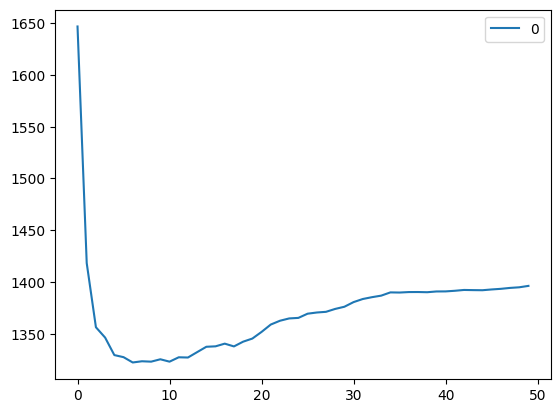

In [213]:
#plotting the rmse values against k values
curve=pd.DataFrame(rmse_val) #elbow curve
curve.plot()

In [214]:
model = neighbors.KNeighborsRegressor(n_neighbors = 7)

model.fit(x_train, y_train)  #fit the model
pred=model.predict(x_test) #make prediction on test set
error = sqrt(mean_squared_error(y_test,pred)) #calculate rmse
error

1322.1899895352883

In [215]:
from sklearn import metrics
import numpy as np

In [216]:
print("Accuracy:",metrics.r2_score(y_test,pred))
print("MAE     :",metrics.mean_absolute_error(y_test,pred))
print("MSE     :",metrics.mean_squared_error(y_test,pred))
print("RMSE    :",np.sqrt(metrics.mean_squared_error(y_test,pred)))

Accuracy: 0.44356677350611395
MAE     : 955.4642521481646
MSE     : 1748186.3684273257
RMSE    : 1322.1899895352883
